In [426]:
%pip install numpy pandas seaborn torch torchvision scikit-learn matplotlib graphviz kagglehub

Note: you may need to restart the kernel to use updated packages.


In [427]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sajjadtahmasebi/wind-turbine-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/kitton/.cache/kagglehub/datasets/sajjadtahmasebi/wind-turbine-dataset/versions/1


In [428]:
import pandas as pd


df = pd.read_csv(
    "/Users/kitton/.cache/kagglehub/datasets/sajjadtahmasebi/wind-turbine-dataset/versions/1/wind_turbine_dataset.csv"
)

df = df[pd.to_numeric(df["energy_output"], errors="coerce").notnull()]

df["energy_output"] = df["energy_output"].apply(
    lambda x: 0 if x <= 500 else (1 if x <= 600 else 2)
)

In [429]:
df

,wind_speed,motor_temperature,blade_angle,vibration_level,humidity,air_pressure,energy_output,turbine_status
0,12.490802,56.563558,1.919750,8.618620,28.982391,963.680636,0,needs to be repaired
1,24.014286,22.334208,37.282708,7.893506,74.230604,1057.022743,2,off
2,19.639879,56.735620,11.218841,2.810425,63.106870,995.511060,0,needs to be repaired
3,16.973170,25.380116,12.777181,4.197177,65.321011,1032.785998,0,needs to be repaired
4,8.120373,62.620654,10.181038,5.076866,37.200880,934.721246,0,needs to be repaired
...,...,...,...,...,...,...,...,...
34995,13.688071,55.663792,14.238366,7.877179,53.960014,1073.243533,0,needs to be repaired
34996,14.271533,76.796947,8.328146,1.801420,79.767302,1093.872967,0,needs to be repaired
34997,15.593338,75.255110,26.618267,5.302510,51.949326,1048.203685,0,needs to be repaired
34998,24.351366,32.027862,6.324844,1.031443,57.138669,973.408237,1,optimal


In [430]:
import torch.nn as nn
import torch
import pandas as pd
from sklearn.model_selection import train_test_split

# from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

In [431]:
df.dropna(inplace=True)  # Drop rows with NaN
X = df.drop(["energy_output", "turbine_status"], axis=1)[:-1].values
y = df["energy_output"][:-1].values

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.long)

batch_size = 16
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [432]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, output_dim),
        )

    def forward(self, x):
        return self.layers(x)

In [433]:
def train(
    model, train_loader, criterion, optimizer, epochs=50, scheduler=None, lambda_lr=None
):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        train_acc = 0
        train_loss = 0

        for X_batch, y_batch in tqdm(
            train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"
        ):
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            if lambda_lr:
                l2_norm = sum(p.pow(2.0).sum() for p in model.parameters())
                loss = loss + lambda_lr * l2_norm

            loss.backward()
            optimizer.step()

            if scheduler:
                scheduler.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_acc += (predicted == y_batch).sum().item()

        avg_train_loss = train_loss / len(train_dataset)
        avg_train_acc = train_acc / len(train_dataset)

        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_acc)

        model.eval()
        val_acc = 0
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in tqdm(
                test_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"
            ):
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_acc += (predicted == y_batch).sum().item()

        avg_val_loss = val_loss / len(test_dataset)
        avg_val_acc = val_acc / len(test_dataset)
        val_losses.append(avg_val_loss)
        val_accuracies.append(avg_val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} - "
            f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}"
        )

    return train_losses, train_accuracies, val_losses, val_accuracies

In [434]:
from torch import optim


def get_optimizer_scheduler(
    optimizer_name, model_parameters, lr, scheduler_name=None, weight_decay=0.0
):
    if optimizer_name == "SGD":
        optimizer = optim.SGD(
            model_parameters, lr=lr, momentum=0.9, weight_decay=weight_decay
        )
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model_parameters, lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(
            model_parameters, lr=lr, alpha=0.9, weight_decay=weight_decay
        )
    elif optimizer_name == "Adagrad":
        optimizer = optim.Adagrad(model_parameters, lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError("Unsupported optimizer")

    scheduler = None
    if scheduler_name == "ExponentialLR":
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
    elif scheduler_name == "StepLR":
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

    return optimizer, scheduler

In [435]:
model = MLP(input_dim=X_train_tensor.shape[1], output_dim=3)

criterion = nn.CrossEntropyLoss()


optimizer, scheduler = get_optimizer_scheduler(
    "Adam", model.parameters(), lr=0.0001, scheduler_name=None
)
epochs = 100

train_losses, train_accuracies, val_losses, val_accuracies = train(
    model, train_loader, criterion, optimizer, epochs=epochs, scheduler=scheduler
)

Epoch 1/100 - Validation: 100%|██████████| 438/438 [00:00<00:00, 5574.15it/s]


Epoch 1/100 - Train Loss: 0.0444, Train Acc: 0.7320, Val Loss: 0.0309, Val Acc: 0.8430


Epoch 2/100 - Validation: 100%|██████████| 438/438 [00:00<00:00, 5620.07it/s]


Epoch 2/100 - Train Loss: 0.0304, Train Acc: 0.8025, Val Loss: 0.0217, Val Acc: 0.8633


Epoch 3/100 - Validation: 100%|██████████| 438/438 [00:00<00:00, 5638.21it/s]


...

Epoch 98/100 - Train Loss: 0.0189, Train Acc: 0.8662, Val Loss: 0.0158, Val Acc: 0.8921


Epoch 99/100 - Validation: 100%|██████████| 438/438 [00:00<00:00, 5797.79it/s]


Epoch 99/100 - Train Loss: 0.0186, Train Acc: 0.8672, Val Loss: 0.0159, Val Acc: 0.8903


Epoch 100/100 - Validation: 100%|██████████| 438/438 [00:00<00:00, 5771.98it/s]

Epoch 100/100 - Train Loss: 0.0189, Train Acc: 0.8651, Val Loss: 0.0161, Val Acc: 0.8841


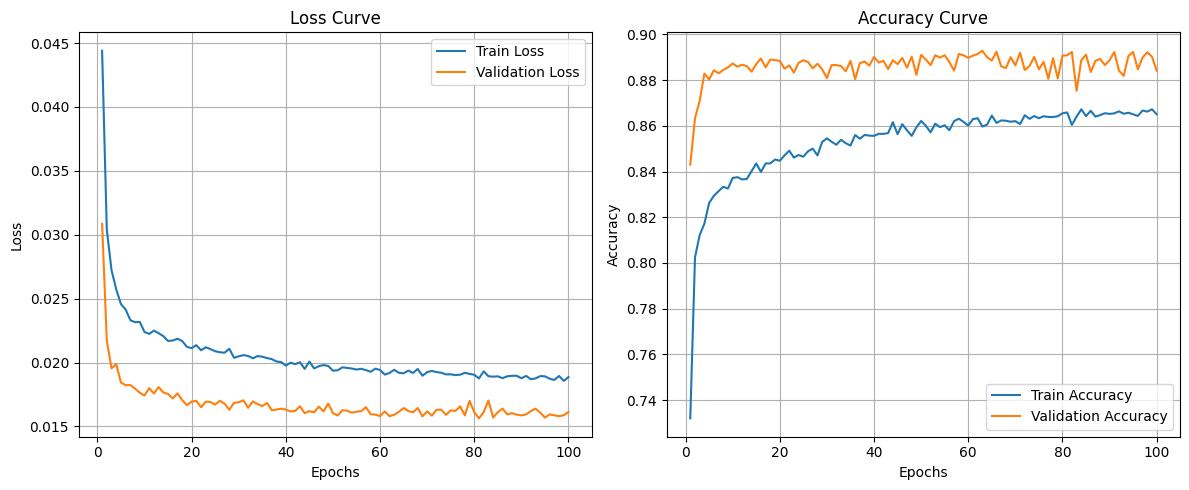

In [436]:
epochs_range = list(range(1, epochs + 1))

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
axs[0].plot(epochs_range, train_losses, label="Train Loss")
axs[0].plot(epochs_range, val_losses, label="Validation Loss")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].set_title("Loss Curve")
axs[0].legend()
axs[0].grid(True)

# Plot Accuracy
axs[1].plot(epochs_range, train_accuracies, label="Train Accuracy")
axs[1].plot(epochs_range, val_accuracies, label="Validation Accuracy")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].set_title("Accuracy Curve")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


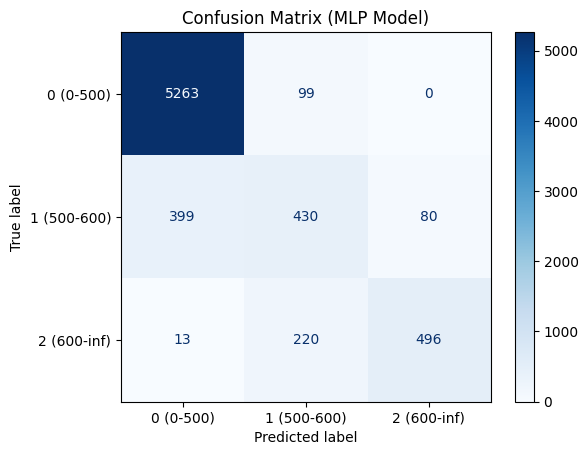

In [437]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    outputs = model(X_valid_tensor)
    y_pred = torch.argmax(outputs, dim=1).cpu().numpy()
    y_true = y_valid_tensor.cpu().numpy()

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0 (0-500)", "1 (500-600)", "2 (600-inf)"])
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix (MLP Model)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()


In [438]:
ans_22_test_dataset = torch.tensor(
    df.drop(["energy_output", "turbine_status"], axis=1)[-1:].values,
    dtype=torch.float32,
)
X_22_test_tensor = ans_22_test_dataset
y_22_test_tensor = torch.tensor(df["energy_output"][-1:].values, dtype=torch.long)

print(X_22_test_tensor, y_22_test_tensor)

tensor([[  23.0938,   25.9511,   14.8527,    5.0332,   85.1859, 1020.8015]]) tensor([2])


In [439]:
model.eval()
with torch.no_grad():
    outputs = model(X_22_test_tensor)
    y_pred = torch.argmax(outputs, dim=1).cpu().numpy()
    print("Y Pred", y_pred)

    y_true = y_22_test_tensor.cpu().numpy()
    print("Y True", y_true)

Y Pred [2]
Y True [2]


In [440]:
X = df.drop(["energy_output", "turbine_status"], axis=1)[-1:]
X["wind_speed"] = 0
ans_23_test_dataset = torch.tensor(
    X.values,
    dtype=torch.float32,
)
X_23_test_tensor = ans_23_test_dataset
y_23_test_tensor = torch.tensor(df["energy_output"][-1:].values, dtype=torch.long)

model.eval()
with torch.no_grad():
    outputs = model(X_23_test_tensor)
    y_pred = torch.argmax(outputs, dim=1).cpu().numpy()
    print("Y Pred", y_pred)

    # y_true = y_23_test_tensor.cpu().numpy()
    # print("Y True", y_true)

Y Pred [0]
